In [42]:
from dotenv import load_dotenv
import os
import pprint as pp
from opensearchpy import OpenSearch
from opensearchpy import helpers

load_dotenv()

OPENSEARCH_USER = os.getenv("OPENSEARCH_USER")
OPENSEARCH_PASSWORD = os.getenv("OPENSEARCH_PASSWORD")
OPENSEARCH_HOST = os.getenv("OPENSEARCH_HOST")
OPENSEARCH_PORT = os.getenv("OPENSEARCH_PORT")

index_name = OPENSEARCH_USER + '_project'

In [43]:
index_name = OPENSEARCH_USER + '_project'
# Create the client with SSL/TLS enabled, but hostname verification disabled.
client = OpenSearch(
    hosts = [{'host': OPENSEARCH_HOST, 'port': OPENSEARCH_PORT}],
    http_compress = True, # enables gzip compression for request bodies
    http_auth = (OPENSEARCH_USER, OPENSEARCH_PASSWORD),
    use_ssl = True,
    url_prefix = 'opensearch_v3',
    verify_certs = False,
    ssl_assert_hostname = False,
    ssl_show_warn = False
)


if client.indices.exists(index=index_name):

    resp = client.indices.open(index=index_name)
    print(resp)

    print("--- INDEX SETTINGS")
    settings = client.indices.get_settings(index=index_name)
    pp.pprint(settings)

    print("--- INDEX MAPPINGS")
    mappings = client.indices.get_mapping(index=index_name)
    pp.pprint(mappings)

    print("--- INDEX #DOCs")
    print(client.count(index=index_name))
else:
    print("Index does not exist.")


{'acknowledged': True, 'shards_acknowledged': True}
--- INDEX SETTINGS
{'uservl07_project': {'settings': {'index': {'creation_date': '1774973269602',
                                             'knn': 'true',
                                             'knn.derived_source': {'enabled': 'true'},
                                             'number_of_replicas': '0',
                                             'number_of_shards': '4',
                                             'provided_name': 'uservl07_project',
                                             'refresh_interval': '1s',
                                             'replication': {'type': 'DOCUMENT'},
                                             'similarity': {'bm25-0-75': {'b': '0.75',
                                                                          'k1': '0.0',
                                                                          'type': 'BM25'},
                                                            

In [44]:
#TODO: experiment with system prompts and instruction formats, choose two different images and create 5 different questions for each.
from openai import OpenAI

BASE_URL = os.getenv("BASE_URL")
API_KEY = os.getenv("API_KEY")
MODEL = os.getenv("MODEL")

#print(repr(BASE_URL), repr(API_KEY), repr(MODEL))
openai_client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
#NOTE: the model parameter is case sensitive, and must be exactly "google/gemma-4-31B-it" for the API to find it

response = openai_client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is the capital of Portugal?"}
    ]
)
print(response.choices[0].message.content)

The capital of Portugal is **Lisbon**.


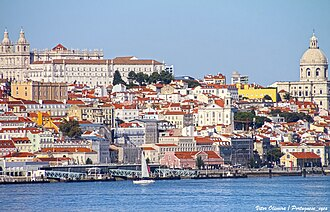

Using system prompt: True
Q: What city is shown in the image?
A: Based on the visual evidence in the image, I cannot identify the specific city with confidence.
--------------------------------------------------

Using system prompt: False
Q: What city is shown in the image?
A: Based on the architecture, the landscape, and the landmarks visible (such as the Praça do Comércio area and the National Pantheon dome on the right), this image shows **Lisbon, Portugal**.
--------------------------------------------------

Using system prompt: True
Q: What time of day is it in the image?
A: Based on the lighting and the shadows visible on the buildings, it appears to be daytime. The scene is brightly lit by direct sunlight, and the shadows are cast sharply, which is characteristic of a clear day. However, it is not possible to determine the exact time of day from the image.
--------------------------------------------------

Using system prompt: False
Q: What time of day is it in the image?
A: 

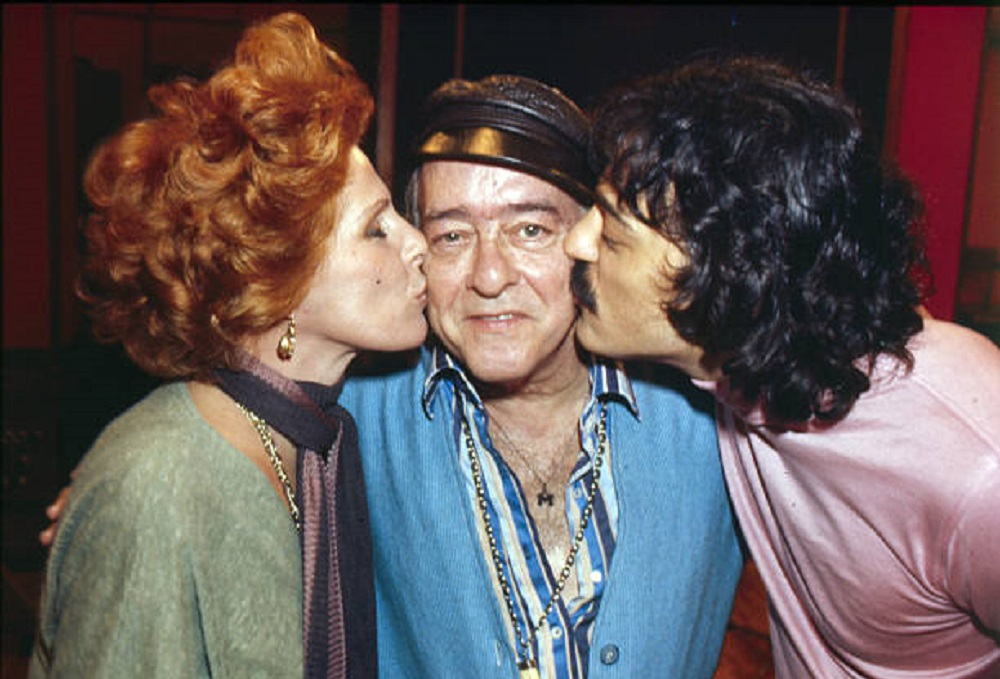

Using system prompt: True
Q: How many people are visible in the image?
A: There are 3 people visible in the image.
--------------------------------------------------

Using system prompt: False
Q: How many people are visible in the image?
A: There are 3 people visible in the image.
--------------------------------------------------

Using system prompt: True
Q: What are the people in the image doing?
A: Two people are kissing a man on his cheeks simultaneously. The woman on the left is kissing his right cheek, and the man on the right is kissing his left cheek. The man in the center is looking forward toward the camera.
--------------------------------------------------

Using system prompt: False
Q: What are the people in the image doing?
A: In the image, two people are kissing a man on the cheeks at the same time. A woman with reddish-blonde hair is kissing him on his right cheek, and a man with long, dark curly hair is kissing him on his left cheek. The man in the middle is looking 

In [54]:
import base64
from IPython.display import Image, display

#openai_client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
image_url = "lisbon.jpg"
def ask_question_about_image(image_url, question, use_system_prompt=True):
    with open(image_url, "rb") as f:
        image_b64 = base64.b64encode(f.read()).decode()
    messages = []
    if use_system_prompt:
        messages.append({"role": "system", "content": "You are an expert visual analyst. When asked about an image, describe only what is directly visible. If you cannot identify a person, place, or object with confidence, explicitly state your uncertainty rather than guessing."})
    messages.append({"role": "user", "content": [
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_b64}"}},
        {"type": "text", "text": question}
    ]})
    response = openai_client.chat.completions.create(
        model=MODEL,
        messages=messages
    )
    return response.choices[0].message.content
image_questions = [
    {
    "image": "lisbon.jpg", 
        "questions":[
            "What city is shown in the image?",
            "What time of day is it in the image?",
            "What architectural styles are visible?",
            "What body of water is visible in the image?",
            "Would this location be a good place for a vacation? Why or why not?"
    ]},
    {"image": "ornella-vanoni-toquinho-vinicius-de-moraes.jpeg",
        "questions":[
        "How many people are visible in the image?",
            "What are the people in the image doing?",
            "What instruments, if any, are visible in the image?",
            "Can you identify any of the people in the image? If so, who are they?",
            "What is the mood or atmosphere of the image? Describe it in detail."
        ]
    }
]

for item in image_questions:
    image = item['image']
    display(Image(filename=image))
    for question in item['questions']:
        for use_system_prompt in [True, False]:
            print(f"Using system prompt: {use_system_prompt}")
            answer = ask_question_about_image(image, question, use_system_prompt=use_system_prompt)
            print(f"Q: {question}\nA: {answer}\n{'-'*50}\n")


## 3.3 Multimodal RAG Pipeline

In [ ]:
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import aiohttp



sbert_model = SentenceTransformer('all-mpnet-base-v2')
bge_model = SentenceTransformer('BAAI/bge-small-en-v1.5')
clip_model = SentenceTransformer('clip-ViT-B-32')
ds = load_dataset("HuggingFaceM4/COCO", split="validation",
                  trust_remote_code=True,
                  storage_options={"client_kwargs": {"timeout": aiohttp.ClientTimeout(total=36000)}}
                  )

In [ ]:
import io

def retrieve_from_query(text_query, index_name=index_name, modality='BM25', top_k=3):
    if modality == 'BM25':
        query_body = {
            "size": top_k,
            "query": {
                "match": {
                    "caption": text_query
                }
            }
        }
    elif modality == 'SBERT':
        query_embedding = sbert_model.encode(text_query, normalize_embeddings=True)
        query_body = {
            "size": top_k,
            "query": {
                "knn": {
                    "SBERT_embedding": {
                        "vector": query_embedding.tolist(),
                        "k": top_k
                    }
                }
            }
        }
    elif modality == 'BGE':
        query_embedding = bge_model.encode(text_query, normalize_embeddings=True)
        query_body = {
            "size": top_k,
            "query": {
                "knn": {
                    "BGE_embedding": {
                        "vector": query_embedding.tolist(),
                        "k": top_k
                    }
                }
            }
        }
    elif modality == 'CLIP':
        query_embedding = clip_model.encode(text_query, normalize_embeddings=True)
        query_body = {
            "size": top_k,
            "query": {
                "knn": {
                    "image_embedding": {
                        "vector": query_embedding.tolist(),
                        "k": top_k
                    }
                }
             }
         }
    else:
        raise ValueError(f"Unsupported modality: {modality}")
    
    response = client.search(index=index_name, body=query_body)
    return response['hits']['hits']

def get_image_from_response(response):
    image_id = response['_source']['image_id']
    image = ds.filter(lambda x: x == int(image_id), input_columns=['imgid'])[0]['image'] 
    return image

def generate_llm_answer(text_query, top_response, original_caption = False):
    
    image = get_image_from_response(top_response)
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG")
    image_b64 = base64.b64encode(buffer.getvalue()).decode()

    if original_caption:
        caption = top_response['_source']['caption']
        user_text = (
            f"Question: {text_query}\n\n"
            f"Context: The following caption was retrieved for this image: \"{caption}\" \n\n"
            "Using both the image and the caption as context, answer the question as accurately as possible."
        )
    else:
        user_text= f"Question: {text_query}\n\nUsing the image as context, answer the question as accurately as possible."
    response = openai_client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful visual assistant.Answer questions about images concisely and accurately, outputting only the answer."},
            {"role": "user", "content": [
                {"type": "image_url", "image_url":
                    {"url": f"data:image/jpeg;base64,{image_b64}"}},
                {"type": "text", "text":user_text}
            ]}
        ]
    )
    return response.choices[0].message.content

In [ ]:
queries= [
    {"keyword": "dog park grass", "question": "What is the dog doing in the image?"},
    {"keyword": "city street", "question": "What is the person doing in the image?"},
    {"keyword": "beach sunset", "question": "What time of day is it in the image?"},
    {"keyword": "child bicicle street", "question": "How old is the child on the bicycle?"},
    {"keyword": "kitchen cooking", "question": "What is happening in the image?"}
]


In [ ]:
for q in queries:
    for modality in ['BM25', 'SBERT', 'BGE', 'CLIP']:
        result = retrieve_from_query(q['keyword'], modality=modality, top_k=1)[0]
        answer_no_caption = generate_llm_answer(q['question'], result)
        answer_caption = generate_llm_answer(q['question'], result, original_caption=True)
        print(f"\n{'='*30}  {modality} {q['keyword']} {'='*30}")
        display(get_image_from_response(result))
        print(f"Caption retrieved for image: {result['_source']['caption']}")
        print(f"Question: {q['question']}")
        print(f"Answer (no caption): {answer_no_caption}")
        print(f"Answer (caption): {answer_caption}")

## 3.4 Agentic Multimodal System

In [ ]:
from smolagents import tool

@tool
def retrieve_by_text(text_query: str, modality: str = 'BM25', top_k: int = 3) -> list[dict]:
    """
    Retrieve image-caption pairs from the index based on a text query.
    Returns a list of dicts with 'image_id' and 'caption' fields.
    To answer a question about the results, you must then call retrieve_image_by_id 
    with the image_id, and then call answer_question_about_image with the returned image.

    Args:
        text_query: A descriptive phrase describing the image content to search for (e.g. 'dog playing in the park').
        modality: Retrieval method to use. One of 'BM25' for keyword search, 'SBERT' or 'BGE' for semantic text search, or 'CLIP' for cross-modal search.
        top_k: Number of results to return.
    """
    results = retrieve_from_query(text_query, modality=modality, top_k=top_k)
    return [{"caption": r['_source']['caption'], "image_id": r['_source']['image_id']} for r in results]

@tool
def retrieve_image_by_id(image_id: str) -> Image:
    """
    Fetch a PIL Image object from the dataset given an image_id string.
    Always call this after retrieve_by_text and before answer_question_about_image.
    The image_id must be the string value from the 'image_id' field of a retrieve_by_text result, 
    not the full dict.

    Args:
        image_id: The image_id string from a retrieve_by_text result (e.g. '123456').
    """
    image = ds.filter(lambda x: x == int(image_id), input_columns=['imgid'])[0]['image'] 
    return image

@tool
def retrieve_by_image(image_id: str, top_k: int = 3) -> list[dict]:
    """
    Retrieve image-caption pairs based on an image query, using CLIP embeddings for retrieval.
    Returns a list of dictionaries containing the caption and image_id for each retrieved result.
    Args:
        image_id: The image_id string from a retrieve_by_text result (e.g. '123456').
        top_k: The number of results to return.
    """
    image = retrieve_image_by_id(image_id)
    query_embedding = clip_model.encode(image, normalize_embeddings=True)
    query_body = {
        "size": top_k,
        "query": {
            "knn": {
                "image_embedding": {
                    "vector": query_embedding.tolist(),
                    "k": top_k
                }
            }
         }
     }
    
    response = client.search(index=index_name, body=query_body)
    results = response['hits']['hits']
    return [{"caption": r['_source']['caption'], "image_id": r['_source']['image_id']} for r in results]

@tool
def answer_question_about_image(image_id: str, question: str, caption: str = None, include_caption_in_context: bool = False) -> str:
    """
    Answer a question about an image using a LVLM.
    Always call retrieve_image_by_id first to get the PIL Image object before calling this tool.
    Do not pass an image_id or a dict — only a PIL Image object is accepted.

    Args:
        image_id: the image_id string from a retrieve_by_text result.
        question: a string containing the question to answer about the image.
        caption: the caption string from retrieve_by_text results, to use as additional context.
        include_caption_in_context: whether to include the caption as context for the LVLM.
    """
    image = retrieve_image_by_id(image_id)
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG")
    image_b64 = base64.b64encode(buffer.getvalue()).decode()

    if include_caption_in_context and caption is not None:
        user_text = (
            f"Question: {question}\n\n"
            f"Context: The following caption was retrieved for this image: \"{caption}\" \n\n"
            "Using both the image and the caption as context, answer the question as accurately as possible."
        )
    else:
        user_text= f"Question: {question}\n\nUsing the image as context, answer the question as accurately as possible."

    response = openai_client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful visual assistant.Answer questions about images concisely and accurately, outputting only the answer."},
            {"role": "user", "content": [
                {"type": "image_url", "image_url":
                    {"url": f"data:image/jpeg;base64,{image_b64}"}},
                {"type": "text", "text":user_text}
            ]}
        ]
    )
    return response.choices[0].message.content
@tool
def show_image(image_id: str) -> None:
    """
    Display an image in the notebook given its image_id.
    
    Args:
        image_id: the image_id string from a retrieve_by_text result.
    """
    image = retrieve_image_by_id(image_id)
    display(image)

In [ ]:
from smolagents import CodeAgent, OpenAIServerModel

agent = CodeAgent(
    tools=[retrieve_by_text, retrieve_image_by_id, retrieve_by_image, answer_question_about_image, show_image],
    model = OpenAIServerModel(
        model_id=MODEL,
        api_base=BASE_URL,
        api_key=API_KEY
    )

)

agent.run("Find images of people surfing and describe what you see. Show the images you find.")

In [ ]:
agent.run("What is happening in image 135684? ")